# 02. Exploratory Data Analysis (EDA) — Commercial Sales & Profitability Diagnostic
**Target Subject:** Commercial Sales Performance, Profitability & Post-Remediation Baseline Diagnostic  
**Entity:** Commercial Dealership & Aftermarket Parts Division (Aden Branch)  
**Schema & Engine:** `gold` (PostgreSQL Data Warehouse) | **Audited Period:** 2023-01-01 to 2025-12-31  
**Executive Mandate:** Revised CDO Analytical Scope & Upstream Reconciliation Bridge

---

### Analytical Scope & Dual-Baseline Architecture
Following the execution of upstream order finalization and ETL ingestion into the `gold` schema:
1. **Realized Commercial Population:** All 18,028 transactional line items in `gold.fact_sales` now evaluate to `is_posted = true AND is_released = true`, establishing a verified total commercial turnover of **1,034,077.26 SAR**.
2. **Reconciliation Bridge (Waterfall):**
   * **Historical Realized Baseline:** **700,807.45 SAR** (12,325 line items, 67.77% share).
   * **Reconciled Unposted Backlog Batch:** **330,919.57 SAR** (5,652 line items, 32.00% share).
   * **Reconciled Cheque Pipeline Batch:** **2,350.24 SAR** (51 line items, 0.23% share).
   * **Total Realized Commercial Turnover:** **1,034,077.26 SAR** (18,028 line items, 100.00%).
3. **Explicit Scope Exclusions:** Excludes customer behavioral analytics (RFM, LTV, churn) due to generic walk-in catch-all customer ID; excludes sales rep commissions (`salesman_code` unpopulated) and cross-center comparisons (single branch '01').
4. **Currency & Costing Governance:** COGS is derived from `quantity * unit_cost_sar`. Inactive fields (`net_price_sar`, discounts, VAT) are excluded.


## 1. Environment Bootstrap & Connection
Initialize database connector, analytical libraries, and corporate plotting theme.


In [1]:
import sys
from pathlib import Path

# Bootstrap project root
_cwd = Path.cwd()
PROJECT_ROOT = str(_cwd if (_cwd / "src").is_dir() else _cwd.parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import query_df

# Formatting & Visual Theme
pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("[OK] Environment initialized. Connected to gold data warehouse.")


python-dotenv could not parse statement starting at line 7


[OK] Environment initialized. Connected to gold data warehouse.


## 2. Revenue Reconciliation Bridge (Dual-Baseline Waterfall)
Reconcile the historical baseline against the reconciled upstream batches ingested into the gold layer.


In [2]:
sql_revenue_bridge = """
SELECT 
    CASE 
        WHEN so.original_posted_status IS NULL OR so.original_posted_status = 'true' THEN '1. Historical Realized Baseline'
        WHEN so.original_posted_status = 'false' AND so.is_cheque = false THEN '2. Reconciled Unposted Backlog'
        WHEN so.original_posted_status = 'false' AND so.is_cheque = true THEN '3. Reconciled Cheque Pipeline'
        ELSE '4. Other Pipeline'
    END AS baseline_component,
    COUNT(DISTINCT so.sales_order_key) AS orders_count,
    COUNT(fs.fact_sales_key) AS line_items_count,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.returned_quantity)::numeric, 2) AS returned_units,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS gross_turnover_sar,
    ROUND((SUM(fs.line_total_sar)::numeric / 1034077.26 * 100)::numeric, 2) AS share_of_total_pct
FROM gold.fact_sales fs
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY 1
ORDER BY 1;
"""
df_bridge = query_df(sql_revenue_bridge)
df_bridge


,baseline_component,orders_count,line_items_count,units_sold,returned_units,gross_turnover_sar,share_of_total_pct
0,1. Historical Realized Baseline,733,12325,"19,155.00",27.00,"700,807.45",67.77
1,2. Reconciled Unposted Backlog,301,5652,"9,200.00",139.00,"330,919.57",32.00
2,3. Reconciled Cheque Pipeline,2,51,74.00,0.00,"2,350.24",0.23


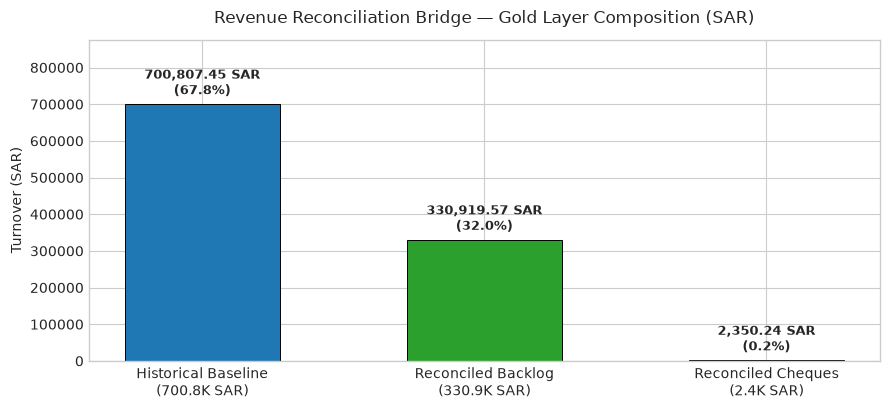

In [3]:
# Visualization of Revenue Reconciliation Bridge
fig, ax = plt.subplots(figsize=(9, 4.2))
labels = ['Historical Baseline\n(700.8K SAR)', 'Reconciled Backlog\n(330.9K SAR)', 'Reconciled Cheques\n(2.4K SAR)']
turnover = df_bridge['gross_turnover_sar']
colors = ['#1f77b4', '#2ca02c', '#17becf']

bars = ax.bar(labels, turnover, color=colors, width=0.55, edgecolor='black', linewidth=0.7)
ax.set_title("Revenue Reconciliation Bridge — Gold Layer Composition (SAR)", fontsize=12, pad=12)
ax.set_ylabel("Turnover (SAR)")
for bar in bars:
    yval = bar.get_height()
    pct = (yval / 1034077.26) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15000, f"{yval:,.2f} SAR\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(turnover) * 1.25)
plt.tight_layout()
plt.show()


## 3. Executive Commercial Sales Performance Dashboard
Evaluating total confirmed realized commercial performance across all 18,028 records in `gold.fact_sales` (`is_posted = true AND is_released = true`).


In [4]:
sql_realized_headline = """
SELECT 
    COUNT(DISTINCT so.sales_order_key) AS total_realized_orders,
    COUNT(fs.fact_sales_key) AS total_line_items,
    ROUND(SUM(fs.quantity)::numeric, 2) AS total_units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_gross_turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS total_cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS realized_gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / SUM(fs.line_total_sar) * 100)::numeric, 2) AS gross_margin_pct,
    ROUND((SUM(fs.line_total_sar) / COUNT(DISTINCT so.sales_order_key))::numeric, 2) AS average_order_value_sar,
    ROUND(SUM(fs.returned_quantity)::numeric, 2) AS total_returned_units,
    ROUND((SUM(fs.returned_quantity) / SUM(fs.quantity) * 100)::numeric, 4) AS overall_return_rate_pct
FROM gold.fact_sales fs
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true;
"""
df_headline = query_df(sql_realized_headline)
df_headline


,total_realized_orders,total_line_items,total_units_sold,realized_gross_turnover_sar,total_cogs_sar,realized_gross_margin_sar,gross_margin_pct,average_order_value_sar,total_returned_units,overall_return_rate_pct
0,1036,18028,"28,429.00","1,034,077.26","781,839.86","252,237.41",24.39,998.14,166.00,0.58


### Headline Commercial Verdicts
* **Realized Gross Turnover:** **1,034,077.26 SAR** (1.034M SAR) across **18,028 line items** and **1,036 distinct transactional orders** (1,894 ERP order headers).
* **Cost of Goods Sold (COGS):** **781,839.86 SAR**, reflecting inventory procurement expenses.
* **Realized Gross Margin:** **252,237.41 SAR** (**24.39%** gross margin), providing healthy operational margin cover.
* **Average Order Value (AOV):** **998.14 SAR** per active order.
* **Return Rate:** **0.5839%** (166 returned units out of 28,429 invoiced units), demonstrating high product dispatch fulfillment stability.


## 4. Longitudinal Time-Series Analysis (2023 – 2025)
Analyze monthly and quarterly turnover, gross margin %, and volume trends across the 36-month audited horizon.


In [5]:
sql_monthly_trends = """
SELECT 
    d.year,
    d.month,
    DATE_TRUNC('month', d.full_date)::DATE AS month_start,
    COUNT(DISTINCT so.sales_order_key) AS orders_count,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_date d ON fs.date_key = d.date_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY d.year, d.month, DATE_TRUNC('month', d.full_date)
ORDER BY month_start;
"""
df_monthly = query_df(sql_monthly_trends)
df_monthly['mom_growth_pct'] = df_monthly['realized_turnover_sar'].pct_change() * 100
df_monthly.head(12)


,year,month,month_start,orders_count,units_sold,realized_turnover_sar,cogs_sar,gross_margin_sar,gross_margin_pct,mom_growth_pct
0,2023,1,2023-01-01,15,258.00,"7,999.92","6,095.29","1,904.64",23.81,NaN
1,2023,2,2023-02-01,15,809.00,"27,976.73","19,159.38","8,817.34",31.52,249.71
2,2023,3,2023-03-01,7,107.00,"3,208.72","2,244.72",963.99,30.04,-88.53
3,2023,4,2023-04-01,9,109.00,"3,846.00","2,681.43","1,164.57",30.28,19.86
4,2023,5,2023-05-01,21,506.00,"10,513.56","7,464.17","3,049.39",29.00,173.36
5,2023,6,2023-06-01,14,162.00,"4,262.58","3,164.59","1,097.98",25.76,-59.46
6,2023,7,2023-07-01,5,70.00,"1,060.53",762.08,298.45,28.14,-75.12
7,2023,8,2023-08-01,20,296.00,"10,135.26","6,429.41","3,705.85",36.56,855.68
8,2023,9,2023-09-01,14,274.00,"10,347.46","7,382.69","2,964.77",28.65,2.09
9,2023,10,2023-10-01,13,129.00,"4,058.91","3,007.67","1,051.24",25.90,-60.77


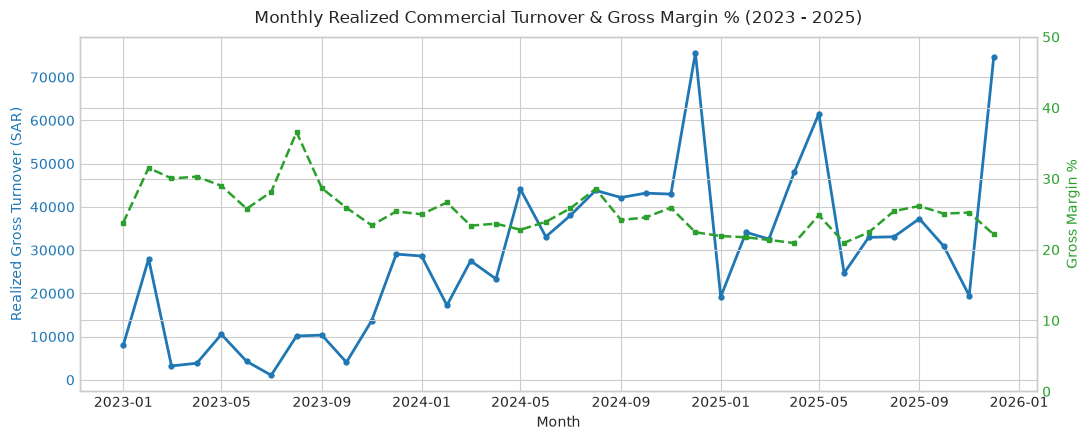

In [6]:
# Visualization: Monthly Commercial Turnover & Margin % Trend
fig, ax1 = plt.subplots(figsize=(11, 4.5))

color = '#1f77b4'
ax1.set_xlabel('Month')
ax1.set_ylabel('Realized Gross Turnover (SAR)', color=color)
line1 = ax1.plot(df_monthly['month_start'], df_monthly['realized_turnover_sar'], color=color, linewidth=2, marker='o', markersize=3.5, label='Turnover SAR')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Gross Margin %', color=color)
line2 = ax2.plot(df_monthly['month_start'], df_monthly['gross_margin_pct'], color=color, linewidth=1.8, linestyle='--', marker='s', markersize=3.5, label='Margin %')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 50)

plt.title("Monthly Realized Commercial Turnover & Gross Margin % (2023 - 2025)", fontsize=12, pad=10)
fig.tight_layout()
plt.show()


In [7]:
sql_quarterly_trends = """
SELECT 
    d.year,
    d.quarter,
    COUNT(DISTINCT so.sales_order_key) AS orders_count,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_turnover_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_date d ON fs.date_key = d.date_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY d.year, d.quarter
ORDER BY d.year, d.quarter;
"""
df_quarterly = query_df(sql_quarterly_trends)
df_quarterly


,year,quarter,orders_count,units_sold,realized_turnover_sar,gross_margin_sar,gross_margin_pct
0,2023,1,37,"1,174.00","39,185.37","11,685.97",29.82
1,2023,2,44,777.00,"18,622.14","5,311.95",28.52
2,2023,3,39,640.00,"21,543.25","6,969.07",32.35
3,2023,4,83,"1,911.00","46,851.37","11,641.92",24.85
4,2024,1,60,"2,366.00","73,374.11","18,176.23",24.77
5,2024,2,92,"2,700.00","100,466.71","23,474.71",23.37
6,2024,3,112,"3,141.00","123,976.85","32,519.41",26.23
7,2024,4,165,"4,258.00","161,702.77","38,679.31",23.92
8,2025,1,81,"1,846.00","85,856.46","18,569.27",21.63
9,2025,2,160,"2,832.00","134,223.23","30,503.01",22.73


## 5. Vehicle Segment & Product Category Diagnostics
Analyze revenue contribution, volume, and margins across vehicle make/models, part categories, and origin quality tiers.


In [8]:
sql_vehicle_models = """
SELECT 
    COALESCE(p.vehicle_make_model, 'Unspecified') AS vehicle_make_model,
    COUNT(DISTINCT p.product_key) AS distinct_products,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_turnover_sar,
    ROUND((SUM(fs.line_total_sar)::numeric / 1034077.26 * 100)::numeric, 2) AS turnover_share_pct,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_product p ON fs.product_key = p.product_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY p.vehicle_make_model
ORDER BY realized_turnover_sar DESC
LIMIT 10;
"""
df_models = query_df(sql_vehicle_models)
df_models


,vehicle_make_model,distinct_products,units_sold,realized_turnover_sar,turnover_share_pct,gross_margin_pct
0,Hyundai Elantra,864,"4,976.00","214,355.64",20.73,24.46
1,Hyundai Sonata,798,"4,699.00","193,239.55",18.69,23.99
2,Hyundai Accent,725,"4,110.00","163,569.96",15.82,26.47
3,Hyundai Tucson,702,"2,279.00","141,299.96",13.66,23.60
4,Hyundai Santa Fe,602,"1,851.00","113,555.78",10.98,21.03
5,Hyundai / Kia (Universal),313,"3,638.00","51,780.80",5.01,31.76
6,Kia Soul,134,268.00,"30,413.20",2.94,21.78
7,Kia Rio,111,323.00,"25,703.37",2.49,23.76
8,Hyundai (General),44,"3,666.00","23,196.21",2.24,23.33
9,Universal / Consumables,47,"1,310.00","16,647.69",1.61,12.94


In [9]:
sql_part_categories = """
SELECT 
    COALESCE(p.part_category, 'Unspecified') AS part_category,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_turnover_sar,
    ROUND((SUM(fs.line_total_sar)::numeric / 1034077.26 * 100)::numeric, 2) AS turnover_share_pct,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_product p ON fs.product_key = p.product_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY p.part_category
ORDER BY realized_turnover_sar DESC
LIMIT 10;
"""
df_categories = query_df(sql_part_categories)
df_categories


,part_category,units_sold,realized_turnover_sar,turnover_share_pct,gross_margin_pct
0,Other Parts & Accessories,"11,027.00","230,585.35",22.30,26.06
1,Shock Absorber & Strut / مساعدات,"1,179.00","86,620.51",8.38,19.70
2,Bumper & Grille / صدامات وشبوك وعلامات,"1,093.00","74,028.51",7.16,24.30
3,Brake Pads & Shoes / فحمات وقماشات فرامل,"1,288.00","52,130.38",5.04,26.61
4,Headlights & Fog Lights / شمعات وكشافات,517.00,"49,975.31",4.83,23.00
5,Radiator & Components / رديترات وأغطية,238.00,"39,271.69",3.80,23.82
6,Engine & Transmission Mount / كراسي محرك وقير,352.00,"32,748.04",3.17,17.17
7,Gaskets & Oil Seals / باكنات وصوف وسيلات,"1,035.00","32,239.39",3.12,28.37
8,Drive Belt & Tensioner / سيور وبكرات وشدادات,674.00,"31,604.69",3.06,24.74
9,"Doors, Mirrors & Windows / أبواب ومرايا وزجاج",905.00,"29,771.18",2.88,26.07


In [10]:
sql_origin_quality = """
SELECT 
    p.origin_quality,
    COUNT(DISTINCT p.product_key) AS distinct_products,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS realized_turnover_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / NULLIF(SUM(fs.line_total_sar), 0) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_product p ON fs.product_key = p.product_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY p.origin_quality
ORDER BY realized_turnover_sar DESC;
"""
df_origin = query_df(sql_origin_quality)
df_origin


,origin_quality,distinct_products,units_sold,realized_turnover_sar,gross_margin_sar,gross_margin_pct
0,Chinese,1821,"6,544.00","333,784.51","80,667.87",24.17
1,Other,916,"7,487.00","251,457.30","60,260.85",23.96
2,Genuine,947,"6,301.00","227,611.95","54,415.03",23.91
3,Korean,1117,"8,097.00","221,223.50","56,893.66",25.72


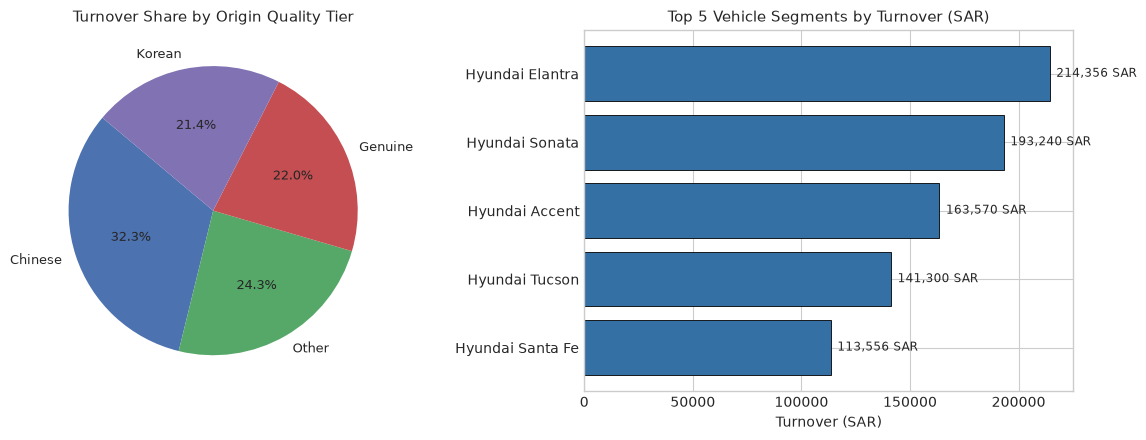

In [11]:
# Visualization: Origin Quality & Top Vehicle Models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Origin Quality Pie
ax1.pie(df_origin['realized_turnover_sar'], labels=df_origin['origin_quality'], autopct='%1.1f%%',
        colors=['#4c72b0', '#55a868', '#c44e52', '#8172b3'], startangle=140, textprops={'fontsize': 9})
ax1.set_title("Turnover Share by Origin Quality Tier", fontsize=11)

# Top 5 Vehicle Models
top_models = df_models.head(5).copy()
bars = ax2.barh(top_models['vehicle_make_model'][::-1], top_models['realized_turnover_sar'][::-1], color='#3470a3', edgecolor='black', linewidth=0.6)
ax2.set_title("Top 5 Vehicle Segments by Turnover (SAR)", fontsize=11)
ax2.set_xlabel("Turnover (SAR)")
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 3000, bar.get_y() + bar.get_height()/2, f"{w:,.0f} SAR", va='center', fontsize=8.5)

plt.tight_layout()
plt.show()


## 6. Product Concentration & Pareto (80/20) Analysis
Determine SKU-level revenue, volume, and margin concentration across all 18,028 line items.


In [12]:
sql_product_pareto = """
WITH sku_totals AS (
    SELECT 
        p.item_code,
        p.item_name,
        p.origin_quality,
        p.vehicle_make_model,
        SUM(fs.quantity) AS units_sold,
        SUM(fs.line_total_sar) AS turnover_sar,
        SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) AS gross_margin_sar
    FROM gold.fact_sales fs
    JOIN gold.dim_product p ON fs.product_key = p.product_key
    JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
    WHERE so.is_posted = true AND so.is_released = true
    GROUP BY p.item_code, p.item_name, p.origin_quality, p.vehicle_make_model
),
ranked_skus AS (
    SELECT 
        item_code,
        item_name,
        origin_quality,
        vehicle_make_model,
        units_sold,
        turnover_sar,
        gross_margin_sar,
        SUM(turnover_sar) OVER (ORDER BY turnover_sar DESC) AS cum_turnover_sar,
        ROUND((SUM(turnover_sar) OVER (ORDER BY turnover_sar DESC) / NULLIF(SUM(turnover_sar) OVER (), 0) * 100)::numeric, 2) AS cum_turnover_pct,
        ROW_NUMBER() OVER (ORDER BY turnover_sar DESC) AS sku_rank
    FROM sku_totals
)
SELECT 
    sku_rank,
    item_code,
    item_name,
    origin_quality,
    vehicle_make_model,
    ROUND(units_sold::numeric, 1) AS units_sold,
    ROUND(turnover_sar::numeric, 2) AS turnover_sar,
    ROUND(gross_margin_sar::numeric, 2) AS gross_margin_sar,
    cum_turnover_pct
FROM ranked_skus
WHERE cum_turnover_pct <= 80.0 OR sku_rank <= 15
ORDER BY sku_rank
LIMIT 15;
"""
df_pareto = query_df(sql_product_pareto)
df_pareto


,sku_rank,item_code,item_name,origin_quality,vehicle_make_model,units_sold,turnover_sar,gross_margin_sar,cum_turnover_pct
0,1,18846-10060M,بلاكات جنسس + النترا + ازيرا 2014 لي,Genuine,Hyundai Elantra,326.00,"9,901.81","2,655.00",0.96
1,2,18814-11051M,بلاكات هونداي عادي وكالة,Genuine,Hyundai (General),747.00,"8,802.35","2,208.16",1.81
2,3,000-10W30EXNOL,زيت اكسينول وسط موديل جديد,Other,Universal / Consumables,290.00,"4,752.63",396.83,2.27
3,4,25500-25001M,بلف حرارة سوناتا 2006 (25=23),Genuine,Hyundai Sonata,86.00,"4,739.40","1,525.74",2.73
4,5,57700-2B210C,علبة سكان تحت سنتافي 07/09,Chinese,Hyundai Santa Fe,6.00,"3,972.52",767.41,3.11
5,6,1,فوائد مبيعات من المحلات المجاورة,Other,Hyundai / Kia (Universal),352.00,"3,942.11","3,942.11",3.49
6,7,51720-38110K,بيرنج هوبس او رمان كفر سوناتا 2004 + سنتافي 2,Korean,Hyundai Sonata,71.00,"3,784.51","1,036.56",3.86
7,8,18845-11160M,بلاكات بلاتين سنتافي توسان 2010 سوناتا شمعتين,Genuine,Hyundai Sonata,116.00,"3,771.15",488.91,4.22
8,9,66400-2S000TAI,كور توسان 2012 تايواني,Other,Hyundai Tucson,8.00,"3,756.00",764.19,4.59
9,10,54584-2H000K,بوشة مقص 2K\2H\2E\1G\3K\3L\2B\3F\2G,Korean,Hyundai Elantra,217.00,"3,537.51","1,033.27",4.93


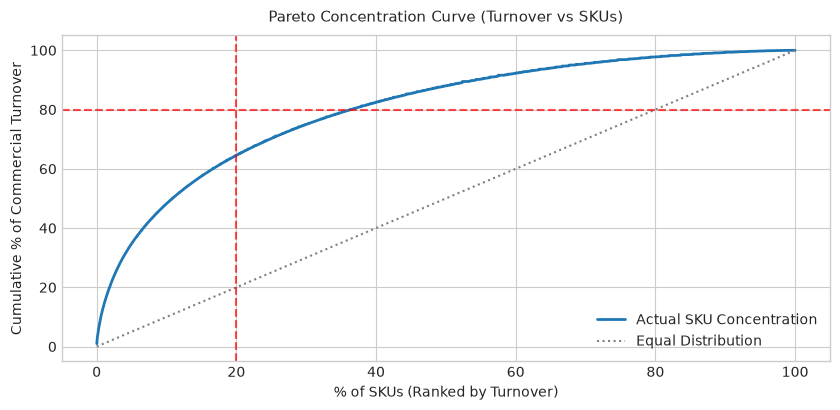

In [13]:
# Pareto Curve: Cumulative Turnover Share vs Product Rank %
sql_pareto_curve = """
WITH sku_totals AS (
    SELECT 
        p.product_key,
        SUM(fs.line_total_sar) AS turnover_sar
    FROM gold.fact_sales fs
    JOIN gold.dim_product p ON fs.product_key = p.product_key
    JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
    WHERE so.is_posted = true AND so.is_released = true
    GROUP BY p.product_key
)
SELECT 
    ROUND((ROW_NUMBER() OVER (ORDER BY turnover_sar DESC)::numeric / COUNT(*) OVER () * 100)::numeric, 2) AS sku_percentile,
    ROUND((SUM(turnover_sar) OVER (ORDER BY turnover_sar DESC) / SUM(turnover_sar) OVER () * 100)::numeric, 2) AS cum_turnover_pct
FROM sku_totals;
"""
df_curve = query_df(sql_pareto_curve)

plt.figure(figsize=(8.5, 4.2))
plt.plot(df_curve['sku_percentile'], df_curve['cum_turnover_pct'], color='#1f77b4', linewidth=2, label='Actual SKU Concentration')
plt.plot([0, 100], [0, 100], color='gray', linestyle=':', label='Equal Distribution')
plt.axvline(20, color='red', linestyle='--', alpha=0.7)
plt.axhline(80, color='red', linestyle='--', alpha=0.7)
plt.title("Pareto Concentration Curve (Turnover vs SKUs)", fontsize=11, pad=10)
plt.xlabel("% of SKUs (Ranked by Turnover)")
plt.ylabel("Cumulative % of Commercial Turnover")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Margin Leakage & Negative-Margin Diagnostics
Investigate the **327 negative-margin transactional lines** (-2,373.41 SAR total erosion) across the pre-reconciliation baseline and reconciled backlog.


In [14]:
sql_negative_margins = """
SELECT 
    CASE 
        WHEN so.original_posted_status IS NULL OR so.original_posted_status = 'true' THEN '1. Historical Baseline Lines'
        ELSE '2. Reconciled Backlog Lines'
    END AS operational_batch,
    COUNT(fs.fact_sales_key) AS loss_lines_count,
    ROUND(SUM(fs.quantity)::numeric, 2) AS loss_units,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS loss_turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS loss_cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_erosion_sar
FROM gold.fact_sales fs
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE fs.unit_price_sar < fs.unit_cost_sar
GROUP BY 1
ORDER BY 1;
"""
df_neg_summary = query_df(sql_negative_margins)
df_neg_summary


,operational_batch,loss_lines_count,loss_units,loss_turnover_sar,loss_cogs_sar,gross_margin_erosion_sar
0,1. Historical Baseline Lines,201,391.00,"7,091.28","8,241.32","-1,150.03"
1,2. Reconciled Backlog Lines,126,532.00,"7,657.76","8,881.13","-1,223.38"


In [15]:
sql_top_loss_products = """
SELECT 
    p.item_code,
    p.item_name,
    p.origin_quality,
    p.vehicle_make_model,
    COUNT(*) AS loss_occurrences,
    ROUND(SUM(fs.quantity)::numeric, 1) AS loss_units,
    ROUND(AVG(fs.unit_price_sar)::numeric, 2) AS avg_sold_price_sar,
    ROUND(AVG(fs.unit_cost_sar)::numeric, 2) AS avg_unit_cost_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS total_margin_erosion_sar
FROM gold.fact_sales fs
JOIN gold.dim_product p ON fs.product_key = p.product_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE fs.unit_price_sar < fs.unit_cost_sar
GROUP BY p.item_code, p.item_name, p.origin_quality, p.vehicle_make_model
ORDER BY total_margin_erosion_sar ASC
LIMIT 10;
"""
df_top_loss = query_df(sql_top_loss_products)
df_top_loss


,item_code,item_name,origin_quality,vehicle_make_model,loss_occurrences,loss_units,avg_sold_price_sar,avg_unit_cost_sar,total_margin_erosion_sar
0,52127-0K030,غطاء جنب الكشاف هايلكس 2013+,Genuine,Hyundai / Kia (Universal),2,141.00,4.13,6.12,-382.61
1,52950-24000K,صاموله كفر اكسنت كوري 99/2001,Korean,Hyundai Accent,1,200.00,1.03,1.63,-121.07
2,31402-27010CZECH,مسطرة توسان ديزل 2 ابوال مشن,Other,Hyundai Tucson,1,1.00,116.22,214.78,-98.56
3,52710-26100C,فلنشة هوبس خلفي سنتافي 2002 ابو حساس,Chinese,Hyundai Santa Fe,2,2.00,56.90,95.69,-77.58
4,24312-26050,بطة تيمت اكسنت ماتركس جتز برايد حجم 1.6+1.4 0,Genuine,Hyundai Accent,1,1.00,48.43,122.02,-73.60
5,23060-2E020M,براصات متحرك STD النتراء 2011 K5,Genuine,Hyundai Elantra,2,8.00,21.49,28.30,-54.50
6,52119-0Z940T,صدام امامي كورلا 2014/2016 تايلاند,Other,Hyundai / Kia (Universal),1,5.00,80.00,90.00,-50.00
7,000-10W40DEXEL,زيت هونداي خفيف موديل جديد هاردكس,Other,Hyundai (General),2,5.00,23.31,31.25,-47.34
8,54813-2S100K,ربلة مشرخ امامي توسان 09/12 كوري,Korean,Hyundai Tucson,1,2.00,6.05,28.50,-44.89
9,000-ATF-4ACDEL,زيت جير او سكان مخلق صناعي موديل جديد,Other,Universal / Consumables,2,8.00,29.40,35.50,-42.60


## 8. Currency Mechanics & Exchange-Rate Sensitivity Analysis
Analyze settlement currencies (SAR vs YER) and evaluate gross margin sensitivity across alternative exchange rate scenarios against the fixed 0.0024 baseline.


In [16]:
sql_currency_breakdown = """
SELECT 
    c.currency_code,
    c.currency_name,
    c.sar_exchange_rate,
    COUNT(fs.fact_sales_key) AS line_items,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_sold,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar,
    ROUND(SUM(fs.quantity * fs.unit_cost_sar)::numeric, 2) AS cogs_sar,
    ROUND(SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar))::numeric, 2) AS gross_margin_sar,
    ROUND((SUM(fs.line_total_sar - (fs.quantity * fs.unit_cost_sar)) / SUM(fs.line_total_sar) * 100)::numeric, 2) AS gross_margin_pct
FROM gold.fact_sales fs
JOIN gold.dim_currency c ON fs.currency_key = c.currency_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
GROUP BY c.currency_code, c.currency_name, c.sar_exchange_rate
ORDER BY turnover_sar DESC;
"""
df_currency = query_df(sql_currency_breakdown)
df_currency


,currency_code,currency_name,sar_exchange_rate,line_items,units_sold,turnover_sar,cogs_sar,gross_margin_sar,gross_margin_pct
0,01,ريال يمني,0.00,15897,"24,157.00","855,413.78","645,047.15","210,366.63",24.59
1,03,ريال سعودي,1.00,2131,"4,272.00","178,663.48","136,792.70","41,870.78",23.44


In [17]:
# Currency Sensitivity Simulation on YER Invoiced Sales
sql_curr_raw = """
SELECT 
    c.currency_code,
    fs.line_total_sar,
    (fs.quantity * fs.unit_cost_sar) AS cogs_sar
FROM gold.fact_sales fs
JOIN gold.dim_currency c ON fs.currency_key = c.currency_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true;
"""
df_curr_raw = query_df(sql_curr_raw)

sar_rev = df_curr_raw[df_curr_raw['currency_code'] == '03']['line_total_sar'].sum()
sar_cogs = df_curr_raw[df_curr_raw['currency_code'] == '03']['cogs_sar'].sum()
yer_rev_base = df_curr_raw[df_curr_raw['currency_code'] == '01']['line_total_sar'].sum()
yer_cogs = df_curr_raw[df_curr_raw['currency_code'] == '01']['cogs_sar'].sum()
raw_yer_nominal = yer_rev_base / 0.0024

scenarios = [0.0018, 0.0020, 0.0022, 0.0024, 0.0026, 0.0028, 0.0030]
sim_rows = []
for rate in scenarios:
    sim_yer_rev = raw_yer_nominal * rate
    tot_rev = sar_rev + sim_yer_rev
    tot_cogs = sar_cogs + yer_cogs
    tot_margin = tot_rev - tot_cogs
    margin_pct = (tot_margin / tot_rev) * 100
    sim_rows.append({
        "Simulated Rate (SAR/YER)": rate,
        "Total Realized Turnover (SAR)": tot_rev,
        "Total COGS (SAR)": tot_cogs,
        "Realized Margin (SAR)": tot_margin,
        "Gross Margin %": margin_pct,
        "Classification": "Reported Baseline (Static)" if rate == 0.0024 else "Estimated Scenario"
    })
df_sensitivity = pd.DataFrame(sim_rows)
df_sensitivity


,Simulated Rate (SAR/YER),Total Realized Turnover (SAR),Total COGS (SAR),Realized Margin (SAR),Gross Margin %,Classification
0,0.00,"820,223.82","781,839.86","38,383.96",4.68,Estimated Scenario
1,0.00,"891,508.30","781,839.86","109,668.44",12.30,Estimated Scenario
2,0.00,"962,792.78","781,839.86","180,952.92",18.79,Estimated Scenario
3,0.00,"1,034,077.26","781,839.86","252,237.41",24.39,Reported Baseline (Static)
4,0.00,"1,105,361.74","781,839.86","323,521.89",29.27,Estimated Scenario
5,0.00,"1,176,646.23","781,839.86","394,806.37",33.55,Estimated Scenario
6,0.00,"1,247,930.71","781,839.86","466,090.85",37.35,Estimated Scenario


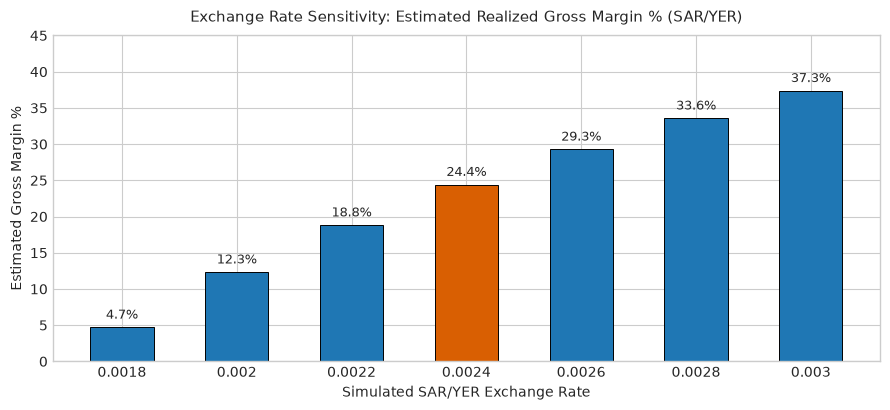

In [18]:
# Visualization of Exchange Rate Sensitivity
plt.figure(figsize=(9, 4.2))
colors = ['#d95f02' if c == "Reported Baseline (Static)" else '#1f77b4' for c in df_sensitivity['Classification']]
bars = plt.bar([str(r) for r in df_sensitivity['Simulated Rate (SAR/YER)']], df_sensitivity['Gross Margin %'], color=colors, width=0.55, edgecolor='black', linewidth=0.7)
plt.title("Exchange Rate Sensitivity: Estimated Realized Gross Margin % (SAR/YER)", fontsize=11, pad=10)
plt.xlabel("Simulated SAR/YER Exchange Rate")
plt.ylabel("Estimated Gross Margin %")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.8, f"{y:.1f}%", ha='center', va='bottom', fontsize=9)
plt.ylim(0, 45)
plt.tight_layout()
plt.show()


## 9. Product Quality & Return-Rate Analysis
Analyze returned items across part categories, vehicle models, and origin tiers.  
> **Analytical Guardrail:** Returns are evaluated exclusively as part defect / dispatch error indicators—**never as customer behavioral attributes**.


In [19]:
sql_return_diagnostics = """
SELECT 
    p.part_category,
    p.origin_quality,
    COUNT(DISTINCT p.product_key) AS affected_skus,
    ROUND(SUM(fs.quantity)::numeric, 1) AS total_sold_units,
    ROUND(SUM(fs.returned_quantity)::numeric, 1) AS returned_units,
    ROUND((SUM(fs.returned_quantity) / NULLIF(SUM(fs.quantity), 0) * 100)::numeric, 2) AS return_rate_pct,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS impacted_turnover_sar
FROM gold.fact_sales fs
JOIN gold.dim_product p ON fs.product_key = p.product_key
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
WHERE so.is_posted = true AND so.is_released = true
  AND fs.returned_quantity > 0
GROUP BY p.part_category, p.origin_quality
ORDER BY returned_units DESC;
"""
df_returns = query_df(sql_return_diagnostics)
df_returns


,part_category,origin_quality,affected_skus,total_sold_units,returned_units,return_rate_pct,impacted_turnover_sar
0,"Doors, Mirrors & Windows / أبواب ومرايا وزجاج",Chinese,3,64.00,43.00,67.19,"1,726.00"
1,Other Parts & Accessories,Chinese,2,40.00,30.00,75.00,"3,400.00"
2,Air Filter / فلاتر هواء,Korean,2,40.00,21.00,52.50,660.00
3,Brake Rotors / هوبات فرامل,Korean,2,50.00,12.00,24.00,"2,600.00"
4,Clutch & Transmission / كلتش وقير,Korean,1,20.00,8.00,40.00,540.00
5,Headlights & Fog Lights / شمعات وكشافات,Chinese,2,10.00,7.00,70.00,515.00
6,Wiper System / منظومة المساحات,Other,1,10.00,6.00,60.00,40.00
7,Other Parts & Accessories,Genuine,2,6.00,6.00,100.00,342.00
8,Other Parts & Accessories,Korean,2,12.00,6.00,50.00,962.00
9,Timing Belt & Chain / سيور وجنازير تيمت,Other,1,21.00,6.00,28.57,573.00


## 10. Remediated Backlog Batch Lineage & Audit Tracking
Detailed audit schedule of the remediated upstream orders ingested under audit batch tracking.


In [20]:
sql_batch_tracking = """
SELECT 
    COALESCE(so.audit_batch_id, 'HISTORICAL-BASE') AS audit_batch_id,
    so.invoice_type,
    so.payment_mode,
    so.is_cheque,
    COUNT(DISTINCT so.sales_order_key) AS orders_count,
    COUNT(fs.fact_sales_key) AS line_items,
    ROUND(SUM(fs.quantity)::numeric, 2) AS units_count,
    ROUND(SUM(fs.line_total_sar)::numeric, 2) AS turnover_sar
FROM gold.fact_sales fs
JOIN gold.dim_sales_order so ON fs.sales_order_key = so.sales_order_key
GROUP BY 1, 2, 3, 4
ORDER BY turnover_sar DESC;
"""
df_batch = query_df(sql_batch_tracking)
df_batch


,audit_batch_id,invoice_type,payment_mode,is_cheque,orders_count,line_items,units_count,turnover_sar
0,HISTORICAL-BASE,06,Cash,False,493,10736,"16,611.00","596,444.67"
1,AUDIT-REC-2026-01,06,Cash,False,172,4615,"7,017.00","244,520.70"
2,AUDIT-REC-2026-01,04,Cash,False,126,895,"2,014.00","78,976.25"
3,HISTORICAL-BASE,04,Cash,False,194,965,"1,610.00","62,131.81"
4,HISTORICAL-BASE,26,Cash,False,11,556,716.00,"32,913.22"
5,HISTORICAL-BASE,24,Cash,False,35,68,218.00,"9,317.74"
6,AUDIT-REC-2026-01,26,Cash,False,3,142,169.00,"7,422.62"
7,AUDIT-REC-2026-01,06,Cheque,True,2,51,74.00,"2,350.24"


## 11. Data Quality & Governance Action Register
Structured matrix of data warehouse anomalies, operational business risks, technical root causes, and recommended controls.


In [21]:
governance_register = [
    {
        "Risk Area": "Customer Master",
        "Finding": "87.14% of turnover mapped to generic walk-in catch-all; ad-hoc memos in name field",
        "Business Impact": "Blocks customer retention, RFM, churn, and credit receivables collection",
        "Remediation Action": "Mandate customer master creation (name, tax ID, phone) for wholesale/credit sales in ERP",
        "Owner": "Branch Operations"
    },
    {
        "Risk Area": "Pricing & Margin Controls",
        "Finding": "327 negative-margin lines (-2,373.41 SAR total) sold below unit cost",
        "Business Impact": "Direct margin leakage and cashier manual override vulnerability",
        "Remediation Action": "Configure automated ERP block preventing POS confirmation when unit_price < unit_cost",
        "Owner": "IT & Sales Mgmt"
    },
    {
        "Risk Area": "Currency Exchange Rates",
        "Finding": "Static scalar rate (0.0024) applied to all YER transactions across 2023-2025",
        "Business Impact": "Distorts reported SAR margins and masks genuine commercial profitability",
        "Remediation Action": "Implement daily/weekly effective market exchange rate table in dim_currency",
        "Owner": "Finance & Treasury"
    },
    {
        "Risk Area": "Order Lifecycle / Backlog",
        "Finding": "801 unposted orders (330,919.57 SAR) and 3 cheques (2,350.24 SAR) remediated upstream",
        "Business Impact": "Previously inflated unposted exposure by 47.55%; resolved in gold layer",
        "Remediation Action": "Execute formal EOD checkout reconciliation SOP (SOP-FIN-OPS-001) daily",
        "Owner": "Branch Accounting"
    },
    {
        "Risk Area": "Inactive Data Fields",
        "Finding": "salesman_code, net_price_sar, discount amounts, and VAT amount are unpopulated (0.00)",
        "Business Impact": "Prevents sales rep performance scorecards and discount effectiveness analysis",
        "Remediation Action": "Enforce cashier/salesman login tracking; activate ERP discount calculation engine",
        "Owner": "ERP Systems Admin"
    }
]
df_gov = pd.DataFrame(governance_register)
df_gov


,Risk Area,Finding,Business Impact,Remediation Action,Owner
0,Customer Master,87.14% of turnover mapped to generic walk-in c...,"Blocks customer retention, RFM, churn, and cre...","Mandate customer master creation (name, tax ID...",Branch Operations
1,Pricing & Margin Controls,"327 negative-margin lines (-2,373.41 SAR total...",Direct margin leakage and cashier manual overr...,Configure automated ERP block preventing POS c...,IT & Sales Mgmt
2,Currency Exchange Rates,Static scalar rate (0.0024) applied to all YER...,Distorts reported SAR margins and masks genuin...,Implement daily/weekly effective market exchan...,Finance & Treasury
3,Order Lifecycle / Backlog,"801 unposted orders (330,919.57 SAR) and 3 che...",Previously inflated unposted exposure by 47.55...,Execute formal EOD checkout reconciliation SOP...,Branch Accounting
4,Inactive Data Fields,"salesman_code, net_price_sar, discount amounts...",Prevents sales rep performance scorecards and ...,Enforce cashier/salesman login tracking; activ...,ERP Systems Admin


## 12. Methodological Assumptions & Scope Limitations
### Summary of Operational Safeguards:
1. **Commercial Turnover:** All commercial figures represent **100% Confirmed Realized Turnover** in the gold warehouse (**1,034,077.26 SAR**).
2. **Reconciliation Lineage:** The 333,269.81 SAR former backlog is tracked via audit lineage (`audit_batch_id = 'AUDIT-REC-2026-01'`).
3. **Excluded Analytics:** Customer retention, RFM, customer rankings, sales representative commissions, multi-branch comparisons, and VAT calculations are excluded due to data model constraints.
4. **Exchange Rate Scenarios:** All currency sensitivity figures are explicitly marked as simulations.

---
**Report Certified By:** Commercial Data Analytics Unit  
**Distribution:** Chief Data Officer, Executive Committee, Commercial Director, Branch Operations
